<a href="https://colab.research.google.com/github/juancopi81/Deep-Learning-Audio-Application-From-Design-to-Deployment/blob/master/Module_2_Lecture_1_Sampling_the_U_net_in_a_smarter_way.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.io import read_image
from torchvision.utils import make_grid, save_image
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else torch.device("cpu"))

In [ ]:
# !mkdir -p emojis

In [ ]:
!mkdir -p weights

## Load Dataset

In [ ]:
dataset_path = "emojis"
annotations_file = "emojis/emoji_annotations.csv"

In [ ]:
labels = pd.read_csv(annotations_file, header=None, usecols=[1])[1].tolist()

In [ ]:
def plot_emojis(emojis_folder, annotations_file):
    """
    Plots all images in a folder in a single figure with 5 columns and 2 rows.
    Each image plot has its corresponding label as the title and shows the axis.

    Args:
        emojis_folder (str): Path to the folder containing the emoji images.
    """

    images = []
    labels = []

    annotations_df = pd.read_csv(annotations_file, names=["image_name", "image_label"])

    for filename in os.listdir(emojis_folder):
        if filename.endswith(".png"):
            img_path = os.path.join(emojis_folder, filename)
            try:
                img = Image.open(img_path).convert("RGB")
                images.append(img)
                label = annotations_df.loc[
                    annotations_df["image_name"] == filename, "image_label"
                ].values[0]
                labels.append(label)
            except Exception as e:
                print(f"Error loading image {filename}: {e}")

    if not images:
        print("No images found in the folder.")
        return

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()  # Flatten the 2x5 array of axes to easily iterate

    for i, (img, label) in enumerate(zip(images, labels)):
        if i < len(
            axes
        ):  # Ensure we don't go out of bounds if there are more images than subplots
            axes[i].imshow(img)
            axes[i].set_title(label)
            axes[i].axis("on")  # Show axis

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

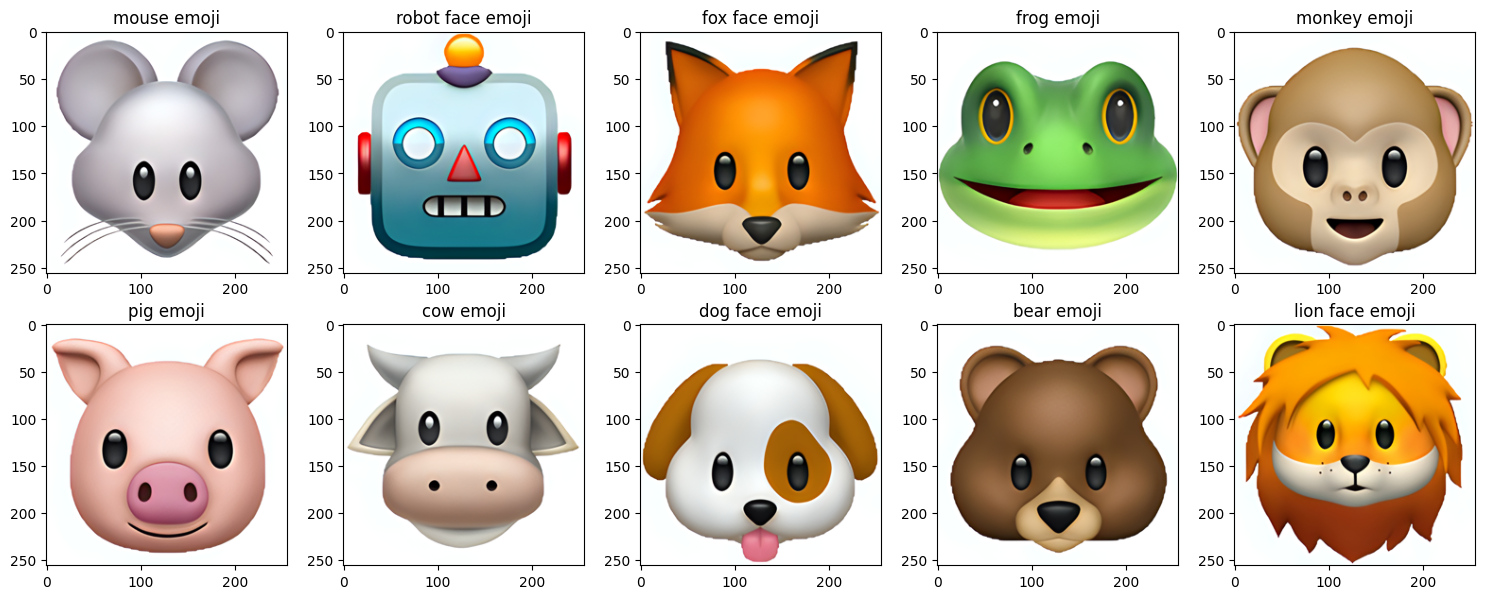

In [ ]:
plot_emojis(dataset_path, annotations_file)

In [ ]:
IMG_HEIGHT = 64
IMG_WIDTH = 64

image_transformations = transforms.Compose(
    [
        transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
        transforms.ConvertImageDtype(torch.float32),  # tensor must be float32. read_image returns uint8 tensor
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

In [ ]:
class CustomEmojiDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_names = pd.read_csv(annotations_file, header=None, usecols=[0])[0].tolist()
        self.img_labels = pd.read_csv(annotations_file, header=None, usecols=[1])[1].tolist()
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_names[idx])
        image = read_image(img_path)  # reads image into a tensor torch.Size([3, 256, 256]). The values of the output tensor are uint8 between 0 and 255.
        label = idx
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

In [ ]:
BATCH_SIZE = 32

emoji_dataset = CustomEmojiDataset(annotations_file, dataset_path, image_transformations)
dataloader = DataLoader(emoji_dataset, batch_size=BATCH_SIZE, shuffle=True,)

In [ ]:
NUM_CLASSES = len(emoji_dataset)

print(NUM_CLASSES)

10


In [ ]:
def plot_dataset(dataset, labels):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    for i in range(len(dataset)):
        image, label = dataset[i]

        label = labels[label]

        # Unnormalize the image for plotting
        image = image * 0.5 + 0.5

        # Convert the tensor to a PIL image for plotting
        img_pil = transforms.ToPILImage()(image)

        axes[i].imshow(img_pil)
        axes[i].set_title(label)
        axes[i].axis("on")  # Ensure axis is visible

    plt.tight_layout()
    plt.show()

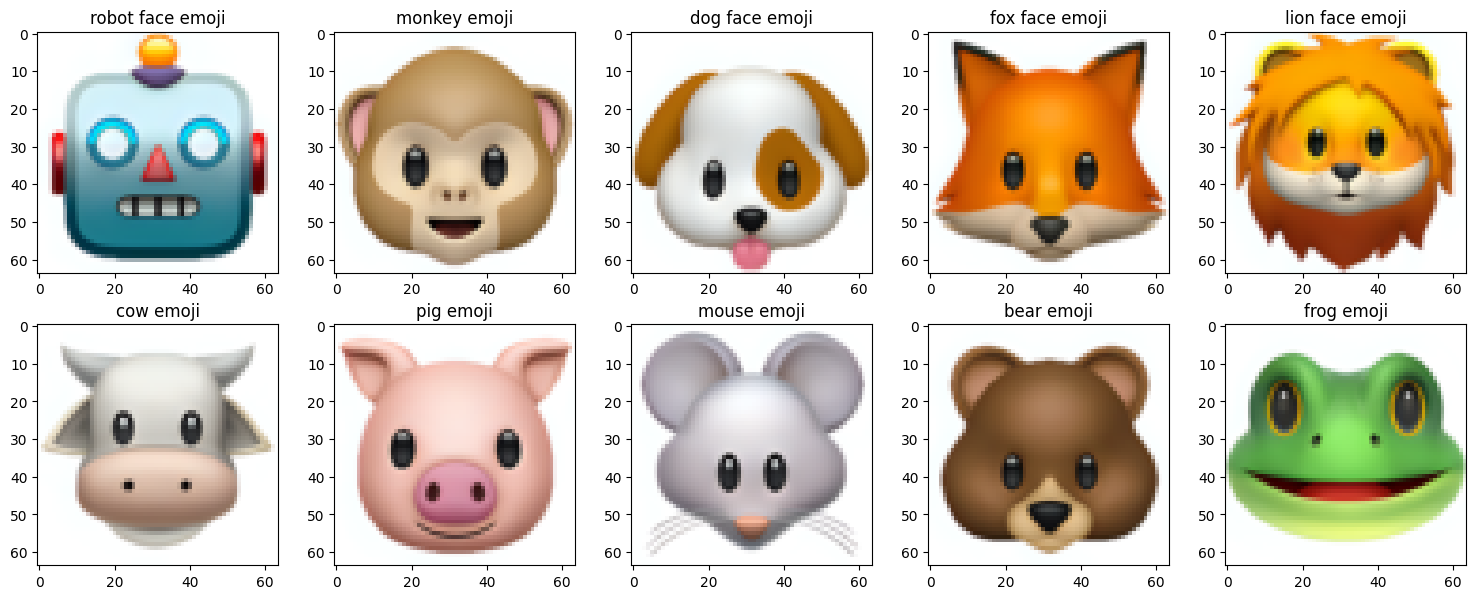

In [ ]:
plot_dataset(emoji_dataset, labels)

## Create Model

In [ ]:
class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int) -> None:
        super(DownBlock, self).__init__()
        layers = [
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, 1, 1),
                nn.GroupNorm(8, out_channels),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, 3, 1, 1),
                nn.GroupNorm(8, out_channels),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, 3, 1, 1),
                nn.GroupNorm(8, out_channels),
                nn.ReLU(),
            ),
            nn.MaxPool2d(2),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int) -> None:
        super(UpBlock, self).__init__()
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, 2, 2),
            nn.Sequential(
                nn.Conv2d(out_channels, out_channels, 3, 1, 1),
                nn.GroupNorm(8, out_channels),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, 3, 1, 1),
                nn.GroupNorm(8, out_channels),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, 3, 1, 1),
                nn.GroupNorm(8, out_channels),
                nn.ReLU(),
            ),
            nn.Sequential(
                nn.Conv2d(out_channels, out_channels, 3, 1, 1),
                nn.GroupNorm(8, out_channels),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, 3, 1, 1),
                nn.GroupNorm(8, out_channels),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, 3, 1, 1),
                nn.GroupNorm(8, out_channels),
                nn.ReLU(),
            ),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = torch.cat((x, skip), 1)
        x = self.model(x)
        return x


class TimeEmbedding(nn.Module):
    def __init__(self, input_dim: int, emb_dim: int) -> None:
        super(TimeEmbedding, self).__init__()

        self.input_dim = input_dim

        self.lin1 = nn.Linear(input_dim, emb_dim)  ## check remove bias keyword
        self.lin2 = nn.Linear(emb_dim, emb_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x initial shape torch.Size([10])
        x = x.view(-1, self.input_dim)  # torch.Size([10, 1]) ; the size -1 is inferred from other dimensions
        x = torch.sin(self.lin1(x))
        x = self.lin2(x)
        return x


class ContextEmbedding(nn.Module):
    def __init__(self, input_dim: int, emb_dim: int) -> None:
        super(ContextEmbedding, self).__init__()

        self.input_dim = input_dim

        self.emd_model = nn.Sequential(
            nn.Linear(input_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x initial shape torch.Size([10, 10])
        x = x.view(-1, self.input_dim)  # torch.Size([10, 10]) not needed since x is already [10,10]
        x = self.emd_model(x)
        return x

In [ ]:
class Unet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        n_feat: int = 256,
        t_input_dim: int = 1,
        c_input_dim: int = 10,
    ) -> None:
        super(Unet, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.n_feat = n_feat

        self.init_conv = nn.Sequential(
            nn.Conv2d(in_channels, n_feat, 3, 1, 1),
            nn.GroupNorm(8, n_feat),
            nn.ReLU(),
            nn.Conv2d(n_feat, n_feat, 3, 1, 1),
            nn.GroupNorm(8, n_feat),
            nn.ReLU(),
            nn.Conv2d(n_feat, n_feat, 3, 1, 1),
            nn.GroupNorm(8, n_feat),
            nn.ReLU(),
        )

        self.down1 = DownBlock(n_feat, n_feat)
        self.down2 = DownBlock(n_feat, 2 * n_feat)
        self.down3 = DownBlock(2 * n_feat, 2 * n_feat)

        self.to_vec = nn.Sequential(nn.AvgPool2d(4), nn.ReLU())

        self.timeembed_1 = TimeEmbedding(t_input_dim, 2 * n_feat)
        self.timeembed_2 = TimeEmbedding(t_input_dim, 2 * n_feat)
        self.timeembed_3 = TimeEmbedding(t_input_dim, n_feat)

        self.contextembed_1 = ContextEmbedding(c_input_dim, 2 * n_feat)
        self.contextembed_2 = ContextEmbedding(c_input_dim, 2 * n_feat)
        self.contextembed_3 = ContextEmbedding(c_input_dim, n_feat)

        self.up0 = nn.Sequential(
            nn.ConvTranspose2d(2 * n_feat, 2 * n_feat, 4, 4),
            nn.GroupNorm(8, 2 * n_feat),
            nn.ReLU(),
        )

        self.up1 = UpBlock(4 * n_feat, 2 * n_feat)
        self.up2 = UpBlock(4 * n_feat, n_feat)
        self.up3 = UpBlock(2 * n_feat, n_feat)
        self.out = nn.Conv2d(2 * n_feat, self.out_channels, 3, 1, 1)

    def forward(self, x: torch.Tensor, t: torch.Tensor, c: torch.Tensor) -> torch.Tensor:

        # x initial shape torch.Size([10, 3, 64, 64])
        x = self.init_conv(x)  # torch.Size([10, 64, 64, 64])

        down1 = self.down1(x)  # torch.Size([10, 64, 32, 32])
        down2 = self.down2(down1)  # torch.Size([10, 128, 16, 16])
        down3 = self.down3(down2)  # torch.Size([10, 128, 8, 8])

        thro = self.to_vec(down3)  # torch.Size([10, 128, 2, 2])

        temb_1 = self.timeembed_1(t).view(-1, self.n_feat * 2, 1, 1)  # torch.Size([10, 128, 1, 1])
        temb_2 = self.timeembed_2(t).view(-1, self.n_feat * 2, 1, 1)  # torch.Size([10, 128, 1, 1])
        temb_3 = self.timeembed_3(t).view(-1, self.n_feat, 1, 1)  # torch.Size([10, 64, 1, 1])

        cemb_1 = self.contextembed_1(c).view(-1, self.n_feat * 2, 1, 1)  # torch.Size([10, 128, 1, 1])
        cemb_2 = self.contextembed_2(c).view(-1, self.n_feat * 2, 1, 1)  # torch.Size([10, 128, 1, 1])
        cemb_3 = self.contextembed_3(c).view(-1, self.n_feat, 1, 1)  # torch.Size([10, 64, 1, 1])

        up0 = self.up0(thro)  # torch.Size([10, 128, 8, 8])
        up1 = self.up1(cemb_1 * up0 + temb_1, down3)  # torch.Size([10, 128, 16, 16])
        up2 = self.up2(cemb_2 * up1 + temb_2, down2)  # torch.Size([10, 64, 32, 32])
        up3 = self.up3(cemb_3 * up2 + temb_3, down1)  # torch.Size([10, 64, 64, 64])

        out = self.out(torch.cat((up3, x), 1))

        return out

In [ ]:
IMG_CH = 3
N_FEAT = 64

unet_model = Unet(in_channels=IMG_CH, out_channels=IMG_CH, n_feat=N_FEAT, c_input_dim=NUM_CLASSES).to(device)

In [ ]:
total_params = sum(p.numel() for p in unet_model.parameters())
print(f"Total number of model parameters: {total_params:,}")

trainable_params = sum(p.numel() for p in unet_model.parameters() if p.requires_grad)
print(f"Total number of trainable model parameters: {trainable_params:,}")

Total number of model parameters: 2,906,371
Total number of trainable model parameters: 2,906,371


## Noise Schedule

In [ ]:
n_T = 500  # number of timesteps

beta1 = 1e-4
beta2 = 0.02

assert beta1 < beta2 < 1.0, "beta1 and beta2 must be in (0, 1)"

beta_t = (beta2 - beta1) * torch.arange(0, n_T + 1, dtype=torch.float32) / n_T + beta1
alpha_t = 1 - beta_t
log_alpha_t = torch.log(alpha_t)
alphabar_t = torch.cumsum(log_alpha_t, dim=0).exp()

sqrtab = torch.sqrt(alphabar_t).to(device)
sqrtmab = torch.sqrt(1 - alphabar_t).to(device)


def add_noise_to_image(x, noise, ts):
    return sqrtab[ts, None, None, None] * x + sqrtmab[ts, None, None, None] * noise

## Train the Model

In [ ]:
n_epoch = 10_000
lr_rate = 2e-5
bern_prob = 0.9

optim = torch.optim.Adam(unet_model.parameters(), lr=lr_rate)
mse_loss = nn.MSELoss()

unet_model.train()

start_time = time.time()

for i in range(n_epoch):

    for image, label in tqdm(dataloader, disable=True):

        optim.zero_grad()

        image = image.to(device)
        label = label.to(device)

        label_one_hot = F.one_hot(label, num_classes=NUM_CLASSES)
        context_mask = torch.bernoulli(torch.full(label_one_hot.size(), bern_prob)).to(
            device
        )

        context = label_one_hot * context_mask  ## torch.Size([10, 10])

        # add noise to image
        noise = torch.randn_like(image)  # ~ N(0, 1)
        ts = torch.randint(1, n_T + 1, (image.shape[0],)).to(image.device)
        x_noise = add_noise_to_image(image, noise, ts)

        # predict noise in image using the U-Net
        noise_pred = unet_model(x_noise, ts / n_T, context)

        # calculate loss
        loss = mse_loss(noise_pred, noise)
        loss.backward()

        optim.step()

    # save model periodically
    if i % 1_000 == 0 or i == int(n_epoch - 1):
        total_time = (time.time() - start_time) / 60
        print(
            f"Epoch {i:>5d} | Loss {loss.item():.5f} | time elapsed {total_time:.2f} min"
        )
        torch.save(unet_model.state_dict(), f"./weights/emoji.pth")

print("\nTraining Complete\n")
total_time = (time.time() - start_time) / 60
print(f"Total time elapsed {total_time:.2f} min")

Epoch     0 | Loss 1.20862 | time elapsed 0.02 min
Epoch  1000 | Loss 0.13013 | time elapsed 0.87 min
Epoch  2000 | Loss 0.04986 | time elapsed 1.71 min
Epoch  3000 | Loss 0.06914 | time elapsed 2.59 min
Epoch  4000 | Loss 0.05955 | time elapsed 3.45 min
Epoch  5000 | Loss 0.02487 | time elapsed 4.29 min
Epoch  6000 | Loss 0.12590 | time elapsed 5.13 min
Epoch  7000 | Loss 0.03159 | time elapsed 5.98 min
Epoch  8000 | Loss 0.02492 | time elapsed 6.83 min
Epoch  9000 | Loss 0.01618 | time elapsed 7.69 min
Epoch  9999 | Loss 0.02049 | time elapsed 8.56 min

Training Complete



## DDPM Sampling with Context

In [ ]:
unet_model.eval();

In [ ]:
alpha_t = alpha_t.to(device)
beta_t = beta_t.to(device)

oneover_sqrta = 1 / torch.sqrt(alpha_t)
mab_over_sqrtmab_inv = (1 - alpha_t) / sqrtmab
sqrt_beta_t = torch.sqrt(beta_t)

In [ ]:
def ddpm_sampling(n_samples: int, size, context) -> torch.Tensor:

    x_i = torch.randn(n_samples, *size).to(device)  # x_T ~ N(0, 1)

    # This samples accordingly to Algorithm 2. It is exactly the same logic.
    for i in range(n_T, 0, -1):
        z = torch.randn(n_samples, *size).to(device) if i > 1 else 0

        t = torch.tensor(i / n_T).repeat(n_samples, 1).to(device)

        predicted_noise = unet_model(x_i, t, context)

        x_i = (
            oneover_sqrta[i] * (x_i - predicted_noise * mab_over_sqrtmab_inv[i])
            + sqrt_beta_t[i] * z
        )

    return x_i

In [ ]:
print("Begin DDPM Sampling (one from each class)")

start_time = time.time()

num_samples = NUM_CLASSES # Set num_samples to the total number of classes

# Create context for each class (0 to NUM_CLASSES-1)
context = F.one_hot(torch.arange(0, NUM_CLASSES), num_classes=NUM_CLASSES).float().to(device)

with torch.no_grad():
    sampled_images = ddpm_sampling(num_samples, (IMG_CH, IMG_HEIGHT, IMG_WIDTH), context)

# save the grid of images
grid = make_grid(sampled_images, normalize=True, value_range=(-1, 1), nrow=5)
save_image(grid, f"./sampled_ddpm_images.png")

total_time = (time.time() - start_time) / 60

print(f"DDPM Sampling Complete | time elapsed {total_time:.2f} min\n")

Begin DDPM Sampling (one from each class)
DDPM Sampling Complete | time elapsed 0.14 min



In [ ]:
def plot_sampled_images(sampled_images, context, labels):
    """
    Plots the sampled images with their corresponding context as titles.

    Args:
        sampled_images (torch.Tensor): Tensor of sampled images.
        context (torch.Tensor): Tensor representing the context for each image (one-hot encoded).
        labels (list): List of original class labels corresponding to the context.
    """
    n_samples = sampled_images.shape[0]
    n_cols = 5
    n_rows = (n_samples + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
    axes = axes.flatten()

    for i in range(n_samples):
        image = (
            sampled_images[i].cpu().numpy().transpose(1, 2, 0)
        )  # Convert from (C, H, W) to (H, W, C)
        image = (image * 0.5 + 0.5).clip(0, 1)  # Unnormalize

        # Find the class index from the one-hot context
        class_idx = torch.argmax(context[i]).item()
        title = labels[class_idx]

        axes[i].imshow(image)
        axes[i].set_title(title)
        axes[i].axis("on")  # Show axis

    # Hide any unused subplots
    for j in range(n_samples, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

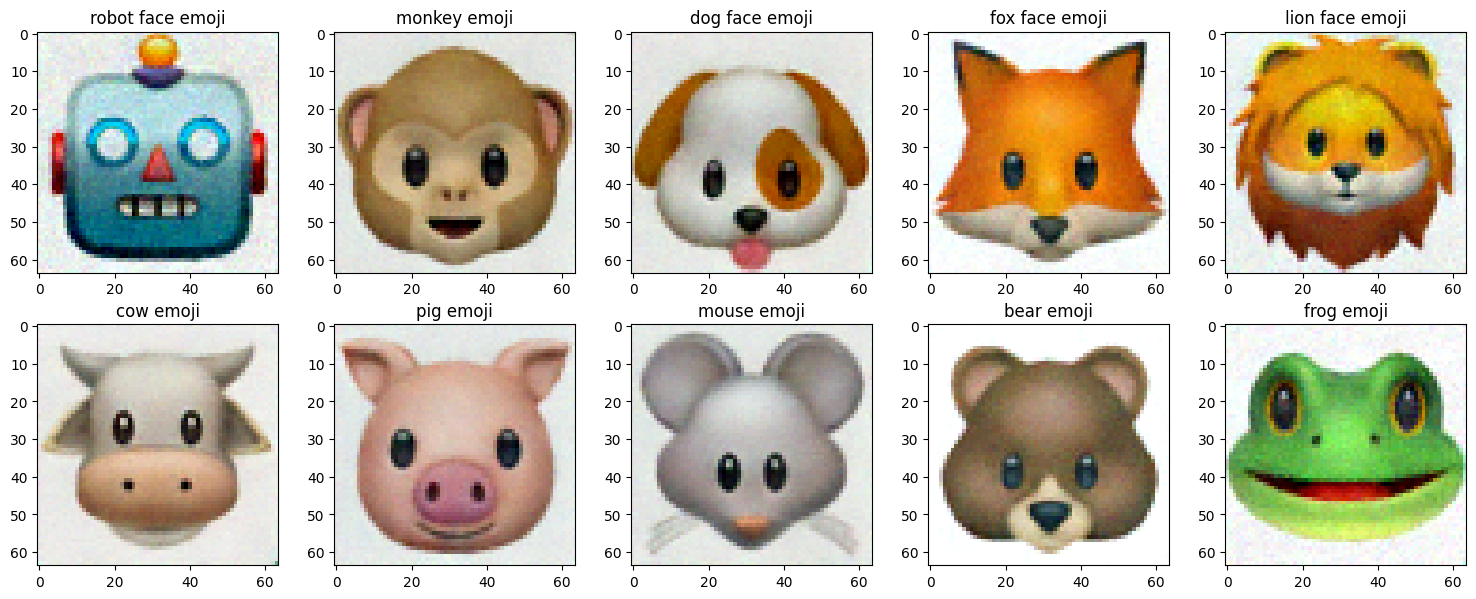

In [ ]:
plot_sampled_images(sampled_images, context, labels)

## DDIM Sampling with Context

Faster than DDPM but usually produces lower quality images


In [ ]:
alphabar_t.to(device);

In [ ]:
def ddim_sampling(n_samples: int, size, context, num_steps) -> torch.Tensor:

    x_i = torch.randn(n_samples, *size).to(device)  # x_T ~ N(0, 1)

    step_size = n_T // num_steps

    for i in range(n_T, 0, -step_size):

        t = torch.tensor(i / n_T).repeat(n_samples, 1).to(device)

        predicted_noise = unet_model(x_i, t, context)

        ab = alphabar_t[i]
        ab_prev = alphabar_t[i - step_size]

        x_i = (
            ab_prev.sqrt() / ab.sqrt() * (x_i - (1 - ab).sqrt() * predicted_noise)
            + (1 - ab_prev).sqrt() * predicted_noise
        )

    return x_i

In [ ]:
print("Begin DDIM Sampling (one from each class)")

start_time = time.time()

num_samples = NUM_CLASSES # Set num_samples to the total number of classes
num_steps = 100

# Create context for each class (0 to NUM_CLASSES-1)
context = F.one_hot(torch.arange(0, NUM_CLASSES), num_classes=NUM_CLASSES).float().to(device)

with torch.no_grad():
    sampled_images = ddim_sampling(num_samples, (IMG_CH, IMG_HEIGHT, IMG_WIDTH), context, num_steps)

# Save the grid of images
grid = make_grid(sampled_images, normalize=True, value_range=(-1, 1), nrow=5)
save_image(grid, f"./sampled_ddim_images_per_class.png")

total_time = (time.time() - start_time) / 60

print(f"DDIM Sampling Complete | time elapsed {total_time:.2f} min\n")

Begin DDIM Sampling (one from each class)
DDIM Sampling Complete | time elapsed 0.03 min



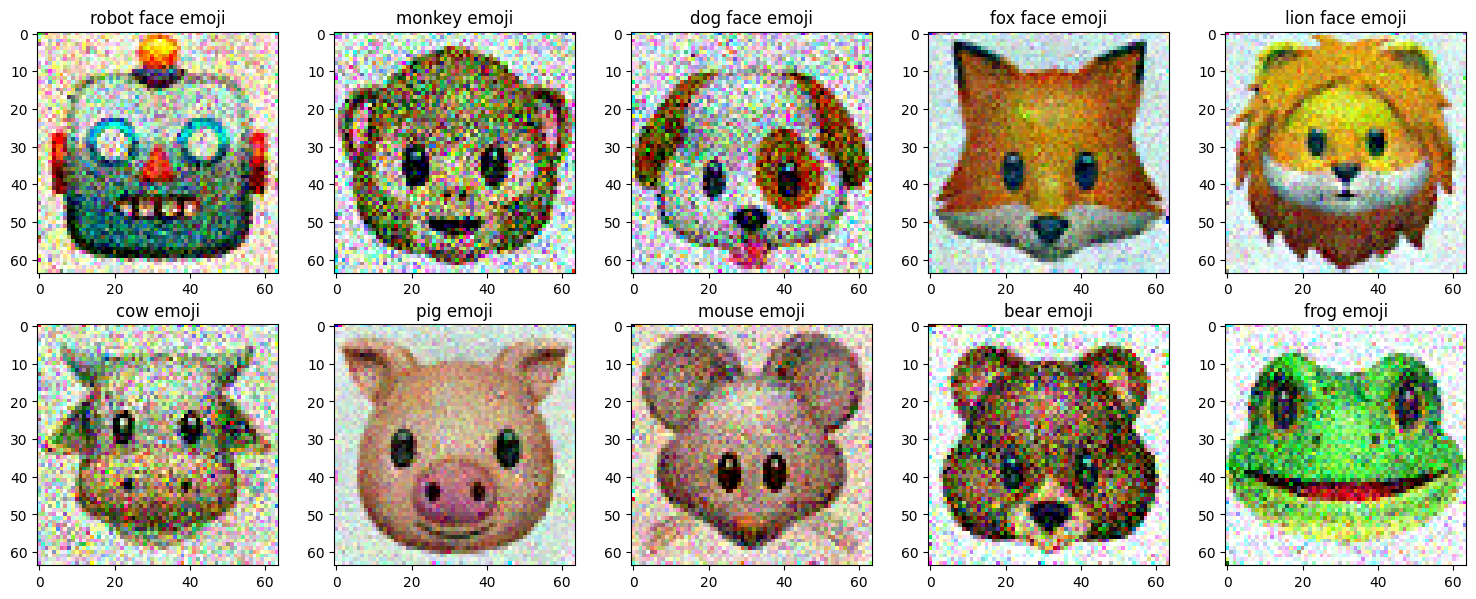

In [ ]:
plot_sampled_images(sampled_images, context, labels)

## Plot Chosen Emoji Using DDPM

In [ ]:
def plot_single_image(sampled_image, context, labels):
    """
    Plots a single sampled image with its corresponding context as title.

    Args:
        sampled_image (torch.Tensor): Tensor of the single sampled image.
        context (torch.Tensor): Tensor representing the context for the image (one-hot encoded).
        labels (list): List of original class labels corresponding to the context.
    """
    # Remove batch dimension if present (assuming it's a single image)
    if sampled_image.dim() == 4:
        sampled_image = sampled_image.squeeze(0)
    if context.dim() == 2:
      context = context.squeeze(0)

    image = (
        sampled_image.cpu().numpy().transpose(1, 2, 0)
    )  # Convert from (C, H, W) to (H, W, C)
    image = (image * 0.5 + 0.5).clip(0, 1)  # Unnormalize

    # Find the class index from the one-hot context
    class_idx = torch.argmax(context).item()
    title = labels[class_idx]

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(title)
    plt.axis("on")  # Show axis
    plt.tight_layout()
    plt.show()

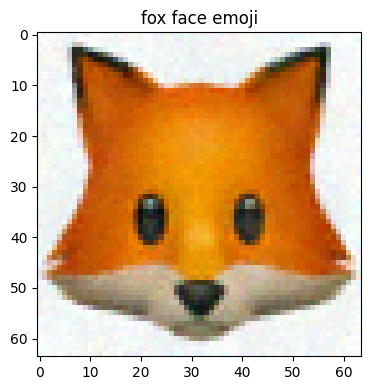

In [ ]:
num_samples = 1

context = torch.tensor([[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]]).float().to(device)

with torch.no_grad():
    sampled_image = ddpm_sampling(num_samples, (IMG_CH, IMG_HEIGHT, IMG_WIDTH), context)

plot_single_image(sampled_image, context, labels)

## Plot Mixed

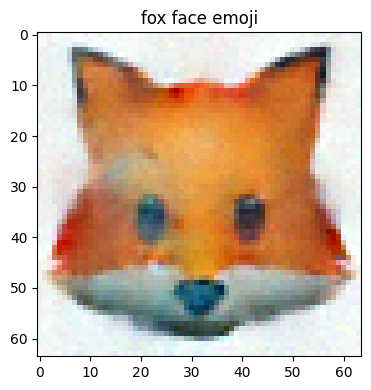

In [ ]:
num_samples = 1

context = torch.tensor([[0.8, 0, 0, 1, 0, 0, 0, 0, 0, 0]]).float().to(device)

with torch.no_grad():
    sampled_image = ddpm_sampling(num_samples, (IMG_CH, IMG_HEIGHT, IMG_WIDTH), context)

plot_single_image(sampled_image, context, labels)